In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Airbnb_Open_Data.csv",low_memory=False)
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [2]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='str')

In [3]:
df.shape

(102599, 26)

In [4]:
df.dtypes

id                                  int64
NAME                                  str
host id                             int64
host_identity_verified                str
host name                             str
neighbourhood group                   str
neighbourhood                         str
lat                               float64
long                              float64
country                               str
country code                          str
instant_bookable                   object
cancellation_policy                   str
room type                             str
Construction year                 float64
price                                 str
service fee                           str
minimum nights                    float64
number of reviews                 float64
last review                           str
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

In [5]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [6]:
df['last review'].head()

0    10/19/2021
1     5/21/2022
2           NaN
3      7/5/2019
4    11/19/2018
Name: last review, dtype: str

In [7]:
df['last review']=pd.to_datetime(df['last review'],errors='coerce')

In [8]:
df['last review'].head()

0   2021-10-19
1   2022-05-21
2          NaT
3   2019-07-05
4   2018-11-19
Name: last review, dtype: datetime64[us]

In [9]:
df['reviews per month'].sample(5)

48939    4.00
4399     0.27
81973    0.25
67502    0.30
71498    0.03
Name: reviews per month, dtype: float64

In [10]:
df.fillna({'reviews per month': 0,'last review':df['last review'].min()},inplace=True)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,$169,1.0,0.0,2012-07-11,0.00,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,$167,1.0,1.0,2015-07-06,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,$198,3.0,0.0,2012-07-11,0.00,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,$109,2.0,5.0,2015-10-11,0.10,3.0,1.0,386.0,NaN,NaN


In [11]:
df.dropna(subset=['NAME','host name'],inplace=True)
df.head(3)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN


In [12]:
df.price.head()

0    $966 
1    $142 
2    $620 
4    $204 
5    $577 
Name: price, dtype: str

In [13]:
df['service fee'].head()

0    $193 
1     $28 
2    $124 
4     $41 
5    $115 
Name: service fee, dtype: str

In [14]:
df['price']=df['price'].str.replace(r'[\$,]','',regex=True).astype(float)
df['service fee']=df['service fee'].str.replace(r'[\$,]','',regex=True).astype(float)

In [15]:
print(df['price'].dtypes)
print(df['service fee'].dtypes)
print(df['price'].head(3))

float64
float64
0    966.0
1    142.0
2    620.0
Name: price, dtype: float64


In [16]:
df.duplicated().sum()


np.int64(539)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  str           
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  str           
 4   host name                       101410 non-null  str           
 5   neighbourhood group             101384 non-null  str           
 6   neighbourhood                   101394 non-null  str           
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  str           
 10  country code                    101288 non-null  str           
 11  ins

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.014100e+05,1.014100e+05,101402.000000,101402.000000,101210.000000,101171.000000,101142.000000,101016.000000,101228.000000,101410,101410.000000,101103.000000,101092.000000,100990.000000
mean,2.920959e+07,4.926155e+10,40.728082,-73.949663,2012.486908,625.381008,125.043998,8.113744,27.511854,2018-05-15 21:26:08.721033,1.163207,3.278558,7.948463,141.164660
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.507574e+07,2.459183e+10,40.688730,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2017-07-30 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.922911e+07,4.912069e+10,40.722300,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-05-23 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.328308e+07,7.399747e+10,40.762750,-73.932340,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-01 00:00:00,1.710000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.626820e+07,2.853703e+10,0.055850,0.049474,5.765130,331.609111,66.313374,30.378014,49.549258,NaN,1.683708,1.285369,32.328974,135.419199


In [19]:
df.isnull().sum()

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       394
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   307
calculated host listings count       318
availability 365                     420
house_rules     

In [20]:
df.drop(columns=['license'],inplace=True)

In [21]:
df['house_rules']=df['house_rules'].fillna("Not Provided")
df['house_rules'].sample(5)

92435     Guests are to clean after themselves after bat...
101672    House rules are just common sense; especially ...
95143                                          Not Provided
52115                                          Not Provided
8505                                           Not Provided
Name: house_rules, dtype: str

In [22]:
df['country code']=df['country code'].fillna('US')
df['country']=df['country'].fillna('United States')

In [23]:
df['neighbourhood group'].unique()

<StringArray>
[     'Brooklyn',     'Manhattan',       'brookln',      'manhatan',
        'Queens',             nan, 'Staten Island',         'Bronx']
Length: 8, dtype: str

In [24]:
correct_neighbourhood={
    'brookln':'Brooklyn',
    'manhatan':'Manhattan'
    }
df['neighbourhood group']=df['neighbourhood group'].replace(correct_neighbourhood)
df['neighbourhood group']=df['neighbourhood group'].fillna('Unknown')

In [25]:
categorical_cols = [
    "host_identity_verified",
    "neighbourhood",
    "cancellation_policy"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [26]:
df['instant_bookable']=df['instant_bookable'].fillna(False).astype(bool)

In [27]:
df.isnull().sum()

id                                  0
NAME                                0
host id                             0
host_identity_verified              0
host name                           0
neighbourhood group                 0
neighbourhood                       0
lat                                 8
long                                8
country                             0
country code                        0
instant_bookable                    0
cancellation_policy                 0
room type                           0
Construction year                 200
price                             239
service fee                       268
minimum nights                    394
number of reviews                 182
last review                         0
reviews per month                   0
review rate number                307
calculated host listings count    318
availability 365                  420
house_rules                         0
dtype: int64

In [28]:
medians={
    'price':df['price'].median(),
    'service fee':df['service fee'].median()
}
df=df.fillna(value=medians)

In [29]:
median_year=df['Construction year'].median()
df['Construction year']=df['Construction year'].fillna(median_year).astype(int)

In [30]:
df['minimum nights'].unique()

array([ 1.000e+01,  3.000e+01,  3.000e+00,  4.500e+01,  2.000e+00,
        1.000e+00,  5.000e+00,  4.000e+00,  9.000e+01,  7.000e+00,
        1.400e+01,  6.000e+01,        nan,  9.000e+00,  3.100e+01,
        6.000e+00,  1.500e+01,  8.000e+00,  4.700e+01,  8.100e+01,
        1.440e+02,  3.710e+02,  1.490e+02,  2.730e+02,  1.310e+02,
        2.750e+02,  3.230e+02,  5.900e+01,  9.900e+01,  2.680e+02,
       -1.000e+01,  1.890e+02,  3.400e+02,  1.280e+02,  3.500e+02,
        1.660e+02,  1.100e+02,  1.420e+02,  3.660e+02,  2.000e+02,
        5.000e+01,  3.990e+02,  1.100e+01,  4.520e+02,  1.300e+01,
        3.455e+03, -5.000e+00,  2.100e+01,  2.700e+01,  1.800e+01,
        3.650e+02, -1.000e+00,  2.000e+01, -1.200e+01,  4.000e+01,
        4.400e+01,  3.980e+02, -2.000e+00,  2.800e+01,  6.500e+01,
       -3.000e+00,  2.900e+01,  5.500e+01,  1.200e+02,  1.800e+02,
        1.220e+02,  1.900e+01,  2.400e+02,  8.800e+01,  1.150e+02,
        1.500e+02,  3.700e+02,  1.600e+01,  8.000e+01,  1.810e

In [31]:
df['minimum nights'] = df['minimum nights'].clip(lower=1, upper=365)
median_nights = df['minimum nights'].median()
df['minimum nights'] = df['minimum nights'].fillna(median_nights).astype(int)
df['minimum nights'].sample(5)

99142     3
67369    14
55971     1
47675     3
6111      2
Name: minimum nights, dtype: int64

In [32]:
df['number of reviews'].unique()
df['number of reviews']=df['number of reviews'].fillna(0).astype(int)

In [33]:
df['review rate number'].unique()
df['review rate number']=df['review rate number'].fillna(0)

In [34]:
df['calculated host listings count'].unique()
df['calculated host listings count']=df['calculated host listings count'].fillna(1).astype(int)

In [35]:
df['availability 365'].unique()

array([ 2.860e+02,  2.280e+02,  3.520e+02,  2.890e+02,  3.740e+02,
        2.240e+02,  2.190e+02,  1.800e+02,  3.750e+02,  1.000e+00,
        1.630e+02,  4.700e+01,  6.800e+01,  1.000e+02,  1.970e+02,
        9.600e+01,  3.250e+02,  3.450e+02,  3.470e+02,  1.930e+02,
        5.400e+01,  9.000e+00,  3.440e+02,  3.720e+02,  1.030e+02,
        1.720e+02,  5.600e+01,  1.050e+02,  1.690e+02,  3.830e+02,
        4.110e+02,  7.600e+01,  4.160e+02,  2.940e+02,  2.140e+02,
        3.560e+02,  1.100e+02,  3.540e+02,  3.300e+01,  4.050e+02,
        8.600e+01,  1.520e+02,  3.530e+02,  2.600e+01,  3.200e+01,
        8.500e+01,        nan,  8.200e+01,  2.010e+02,  3.280e+02,
        3.930e+02,  6.100e+01,  2.670e+02,  1.890e+02,  8.300e+01,
        2.580e+02,  4.000e+02,  3.400e+01,  2.030e+02,  3.500e+01,
        2.800e+02,  4.170e+02,  1.620e+02,  2.420e+02,  2.270e+02,
        1.730e+02,  1.460e+02,  2.430e+02,  4.250e+02,  1.130e+02,
        2.600e+02,  3.950e+02,  2.660e+02,  5.800e+01,  4.100e

In [36]:
df['availability 365'] = df['availability 365'].clip(lower=0, upper=365)
median_availability = df['availability 365'].median()
df['availability 365'] = df['availability 365'].fillna(median_availability).astype(int)

In [37]:
df['service fee'].describe()

count    101410.000000
mean        125.043881
std          66.225691
min          10.000000
25%          68.000000
50%         125.000000
75%         182.000000
max         240.000000
Name: service fee, dtype: float64

In [38]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules'],
      dtype='str')

In [39]:
df.isnull().sum()

id                                0
NAME                              0
host id                           0
host_identity_verified            0
host name                         0
neighbourhood group               0
neighbourhood                     0
lat                               8
long                              8
country                           0
country code                      0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price                             0
service fee                       0
minimum nights                    0
number of reviews                 0
last review                       0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
house_rules                       0
dtype: int64

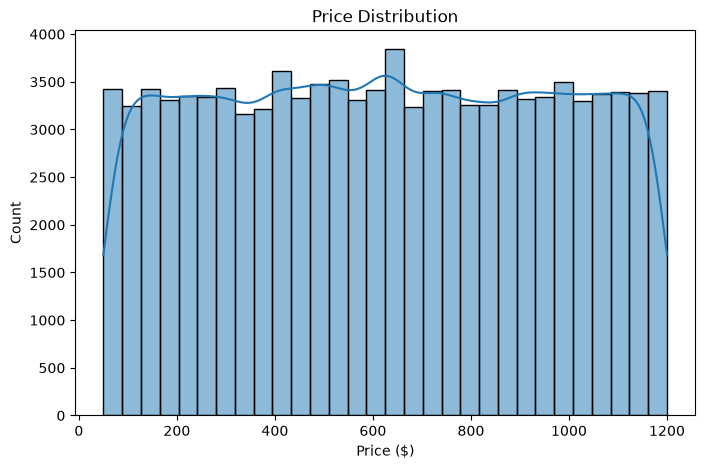

In [40]:
#Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'].dropna(),bins=30,kde=True)
plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

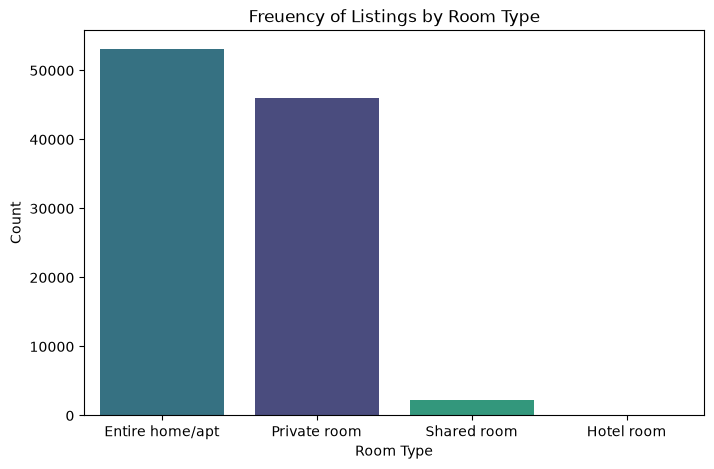

In [41]:
#Room Type Popularity
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='room type',order=df['room type'].value_counts().index,hue=df['room type'],palette='viridis')
plt.title("Freuency of Listings by Room Type")
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

In [42]:
room_percentage=(df['room type'].value_counts(normalize=True).mul(100).round(2))
room_percentage

room type
Entire home/apt    52.39
Private room       45.33
Shared room         2.17
Hotel room          0.11
Name: proportion, dtype: float64

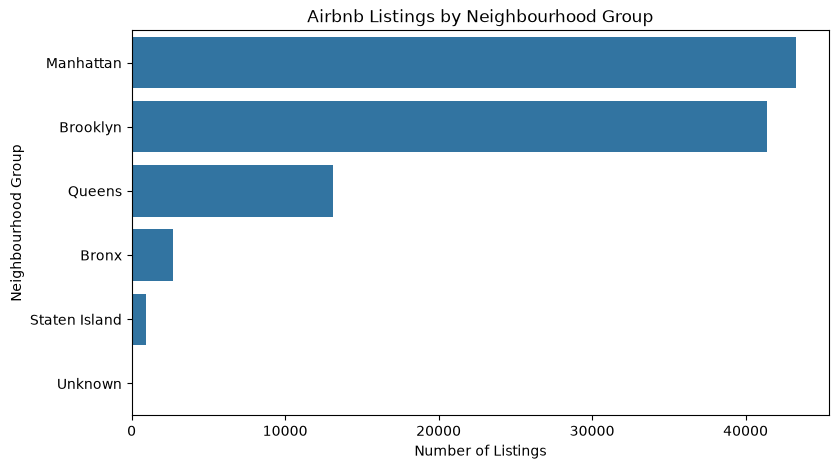

In [43]:
#Listings by Neighbourhood Group
neighbourhood_group=df['neighbourhood group'].value_counts()
plt.figure(figsize=(9,5))
sns.barplot(x=neighbourhood_group.values,y=neighbourhood_group.index)
plt.title("Airbnb Listings by Neighbourhood Group")
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood Group')
plt.show()

In [44]:
#To check whether the service fee is 20% of the actual price
df['fee percentage']=df['service fee']/df['price']
df['fee percentage'].describe()
#df=df.drop(columns=['fee percentage'])

count    101410.000000
mean          0.200249
std           0.018346
min           0.016000
25%           0.199605
50%           0.200000
75%           0.200391
max           2.500000
Name: fee percentage, dtype: float64

In [45]:
price_room=(
    df.groupby("room type")["price"]
    .agg(["mean","median","min","max"])
    .sort_values("mean",ascending=False))
price_room

,mean,median,min,max
room type,,,,
Hotel room,666.391304,643.0,50.0,1193.0
Shared room,634.507741,649.5,50.0,1199.0
Entire home/apt,625.379997,625.0,50.0,1200.0
Private room,624.841582,624.0,50.0,1200.0


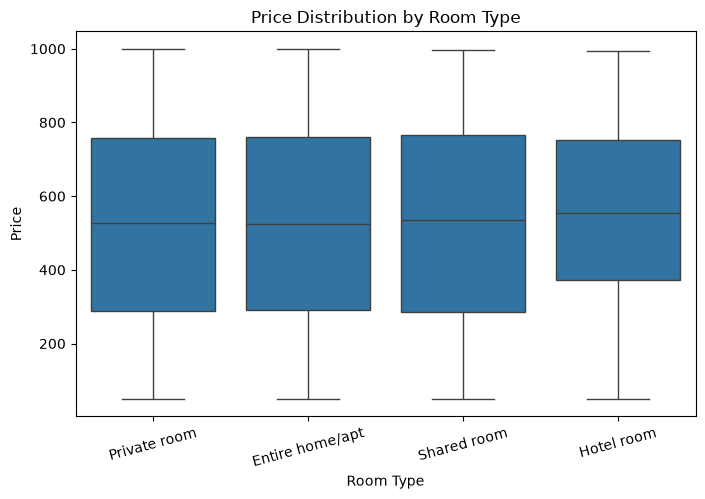

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df[df['price']<=1000],
    x='room type',
    y='price'
)
plt.title("Price Distribution by Room Type")
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.xticks(rotation=15)
plt.show()

In [47]:
neighbourhood_price = (
    df.groupby("neighbourhood group")["price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean")
)

neighbourhood_price

,mean,median,count
neighbourhood group,,,
Manhattan,622.827977,624.0,43279
Staten Island,623.320255,625.0,943
Brooklyn,626.473479,625.0,41364
Bronx,627.627334,630.0,2678
Queens,629.969055,625.0,13120
Unknown,661.730769,648.0,26


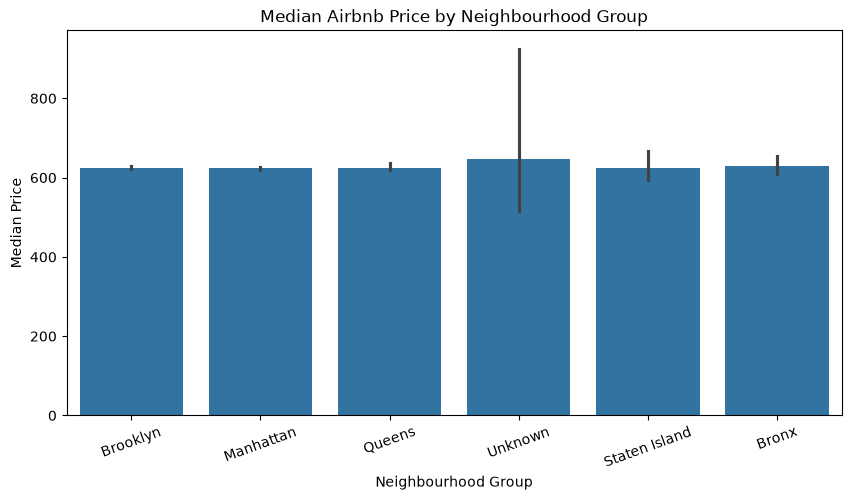

In [48]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="neighbourhood group",
    y="price",
    estimator="median"
)

plt.title("Median Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Median Price")
plt.xticks(rotation=20)
plt.show()

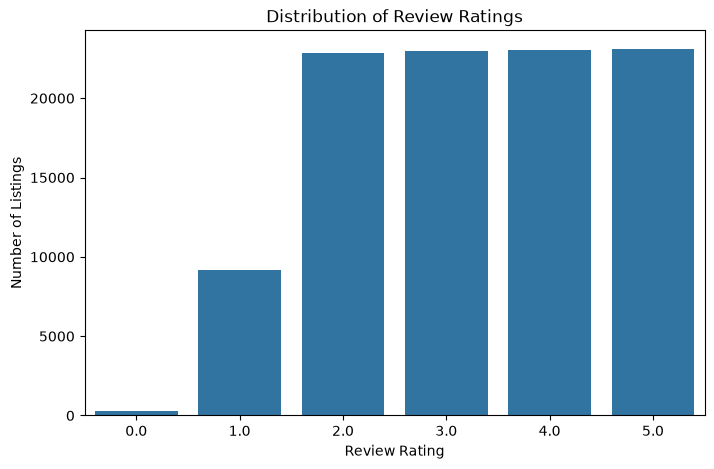

In [49]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='review rate number')
plt.title("Distribution of Review Ratings")
plt.xlabel("Review Rating")
plt.ylabel("Number of Listings")
plt.show()

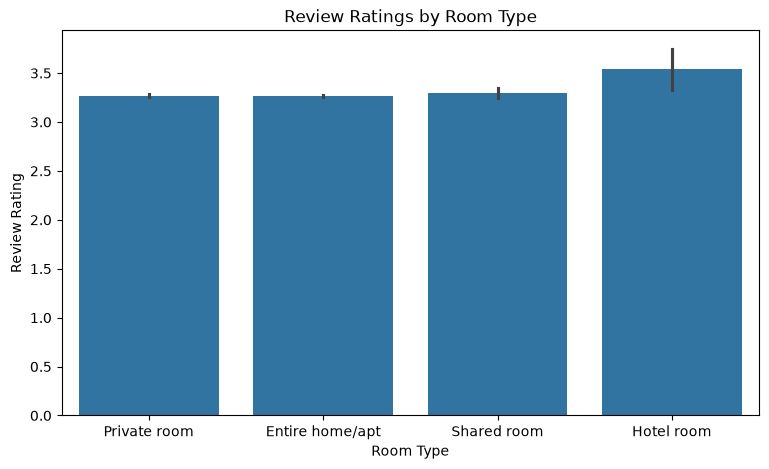

In [50]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df,
    x="room type",
    y="review rate number"
)

plt.title("Review Ratings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Review Rating")
plt.show()

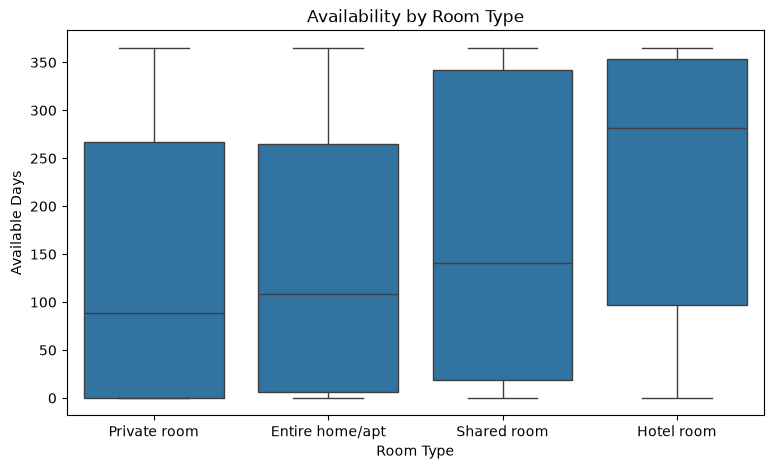

In [51]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="room type",
    y="availability 365"
)

plt.title("Availability by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Available Days")
plt.show()

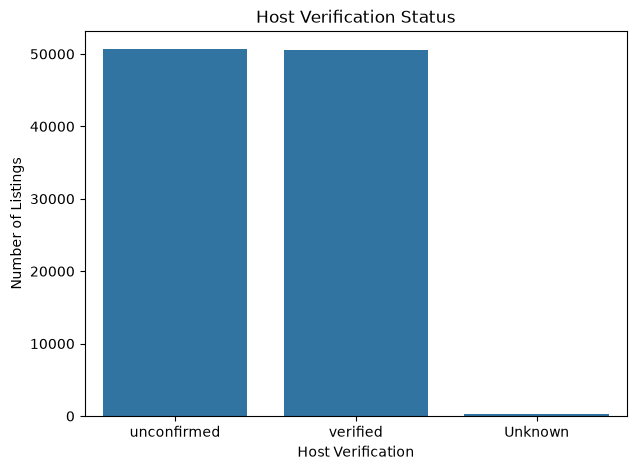

In [52]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="host_identity_verified"
)

plt.title("Host Verification Status")
plt.xlabel("Host Verification")
plt.ylabel("Number of Listings")
plt.show()

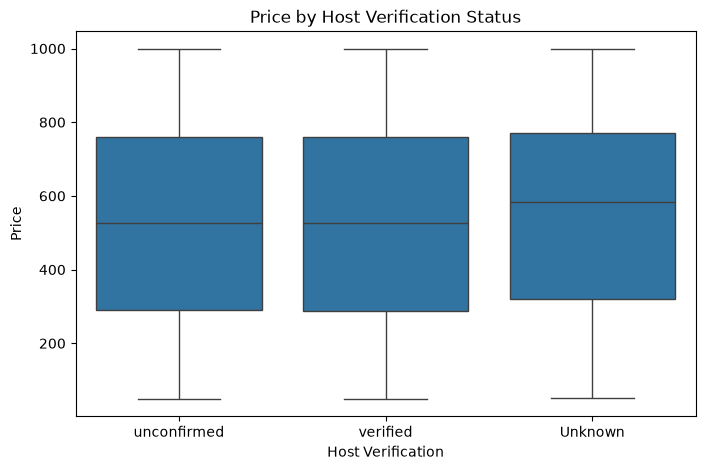

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[df["price"] <= 1000],
    x="host_identity_verified",
    y="price"
)

plt.title("Price by Host Verification Status")
plt.xlabel("Host Verification")
plt.ylabel("Price")
plt.show()

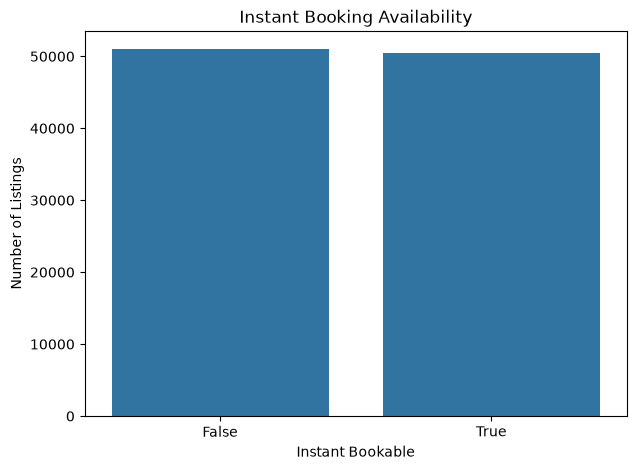

In [54]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="instant_bookable"
)

plt.title("Instant Booking Availability")
plt.xlabel("Instant Bookable")
plt.ylabel("Number of Listings")
plt.show()

In [55]:
df.groupby("instant_bookable")["price"].agg(["mean", "median", "count"])

,mean,median,count
instant_bookable,,,
False,625.392536,625.0,50966
True,625.367556,624.0,50444


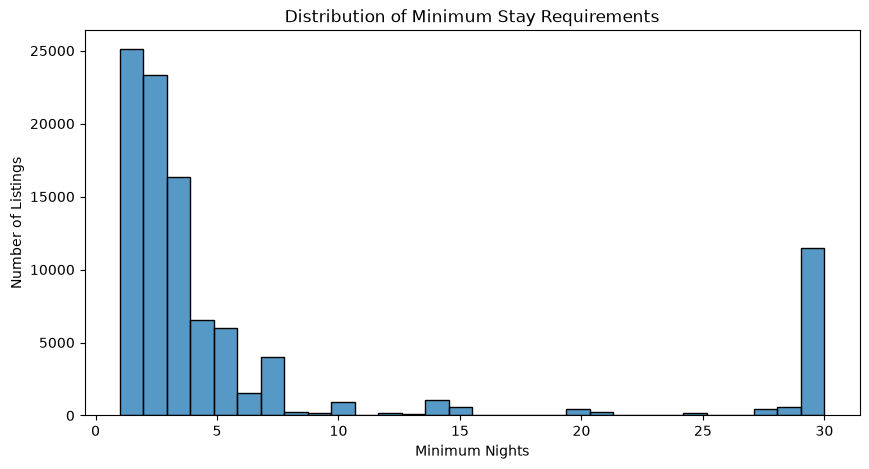

In [56]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df["minimum nights"] <= 30]["minimum nights"],
    bins=30
)

plt.title("Distribution of Minimum Stay Requirements")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.show()

In [57]:
numeric_cols = [
    "price",
    "service fee",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365"
]

corr = df[numeric_cols].corr()

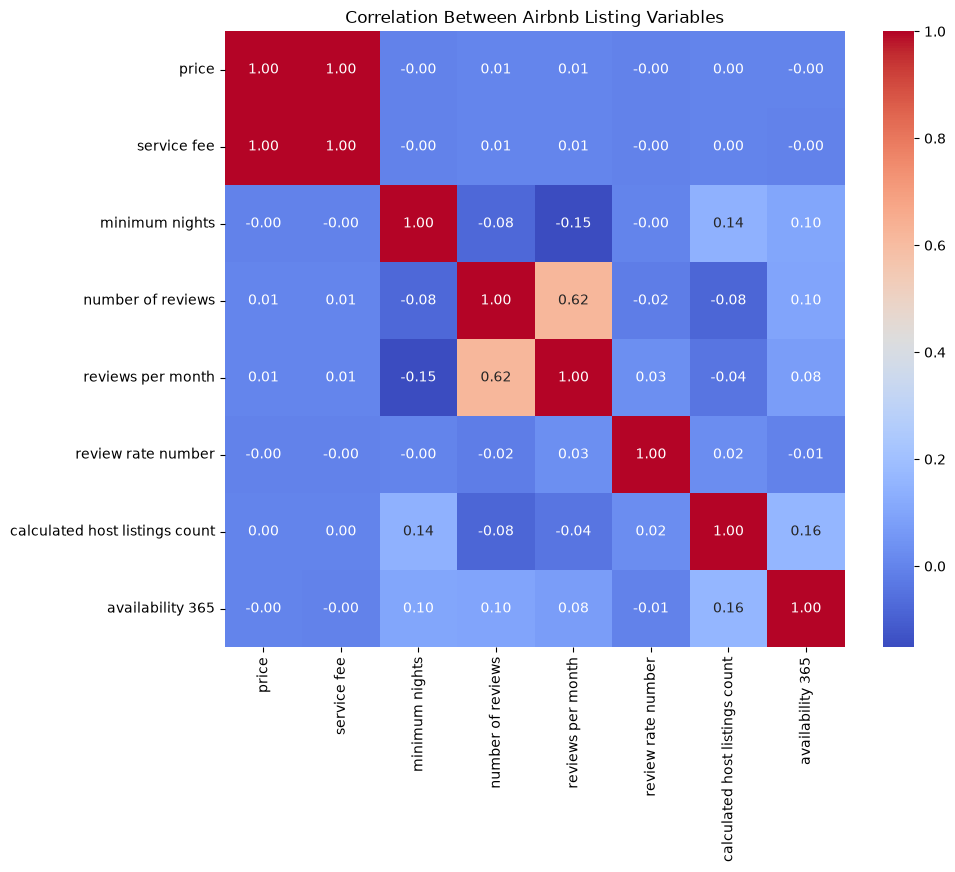

In [58]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Airbnb Listing Variables")
plt.show()